In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.decomposition import PCA
from deeptime.decomposition import TICA

In [3]:
import sys
sys.path.insert(0, "../Scripts")
from util import color_plot

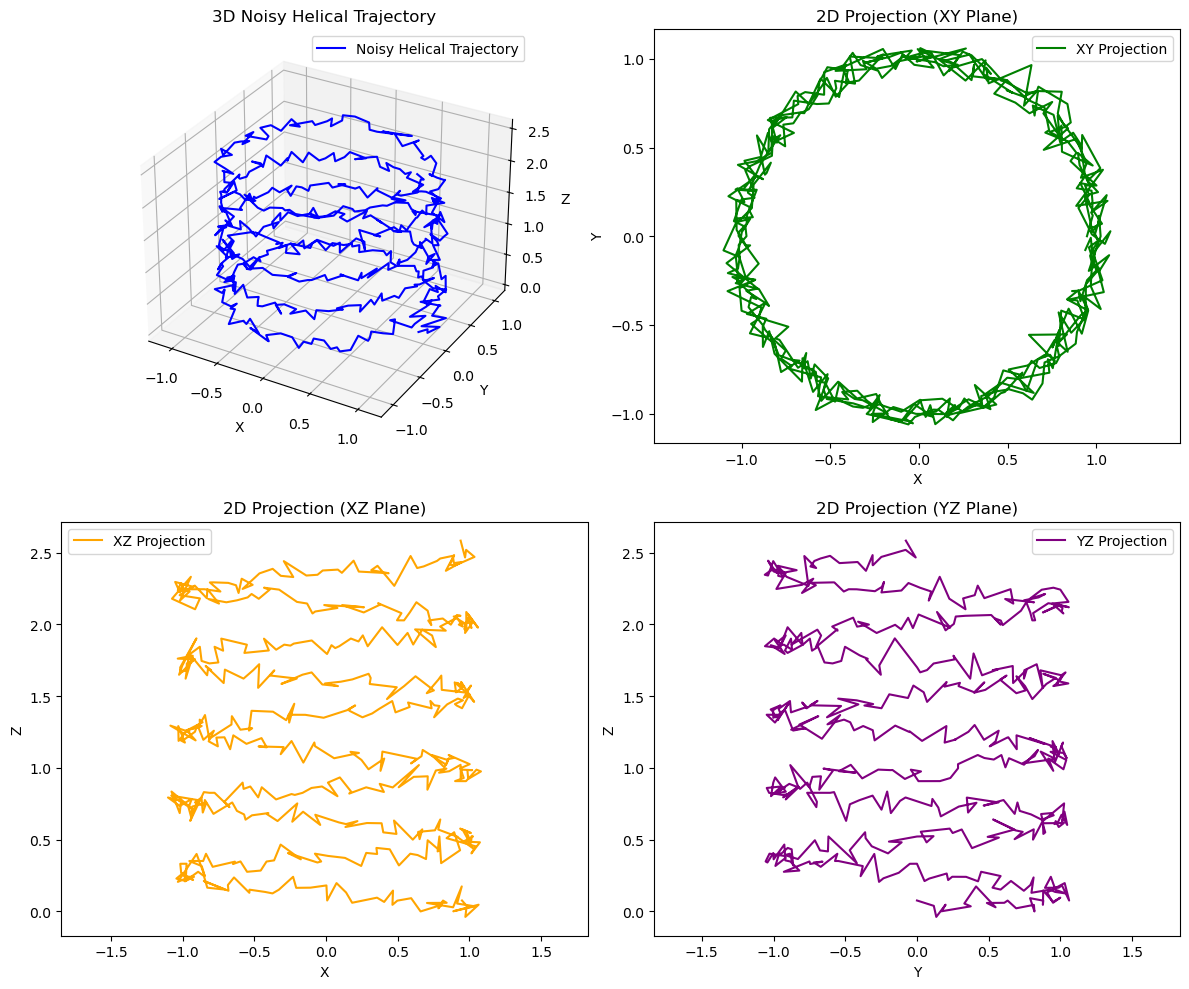

In [4]:
# Function to generate a noisy helical trajectory
def generate_noisy_helix(radius=1.0, pitch=0.5, turns=15, points_per_turn=100, noise_level=0.05):
    t = np.linspace(0, 2 * np.pi * turns, points_per_turn * turns)
    x = radius * np.cos(t) + np.random.normal(0, noise_level, t.shape)
    y = radius * np.sin(t) + np.random.normal(0, noise_level, t.shape)
    z = pitch * t / (2 * np.pi) + np.random.normal(0, noise_level, t.shape)
    return x, y, z

# Function to plot 3D trajectory and its 2D projection
def plot_helix_and_projection(x, y, z):
    fig = plt.figure(figsize=(12, 10))

    # 3D Plot
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.plot(x, y, z, label='Noisy Helical Trajectory', color='blue')
    ax1.set_title('3D Noisy Helical Trajectory')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()

    # 2D Projection (XY plane)
    ax2 = fig.add_subplot(222)
    ax2.plot(x, y, label='XY Projection', color='green')
    ax2.set_title('2D Projection (XY Plane)')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.axis('equal')
    ax2.legend()

    # 2D Projection (XZ plane)
    ax3 = fig.add_subplot(223)
    ax3.plot(x, z, label='XZ Projection', color='orange')
    ax3.set_title('2D Projection (XZ Plane)')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.axis('equal')
    ax3.legend()

    # 2D Projection (YZ plane)
    ax4 = fig.add_subplot(224)
    ax4.plot(y, z, label='YZ Projection', color='purple')
    ax4.set_title('2D Projection (YZ Plane)')
    ax4.set_xlabel('Y')
    ax4.set_ylabel('Z')
    ax4.axis('equal')
    ax4.legend()

    plt.tight_layout()
    plt.show()

# Generate and plot
x, y, z = generate_noisy_helix(turns=5)
plot_helix_and_projection(x, y, z)

## Principal component analysis

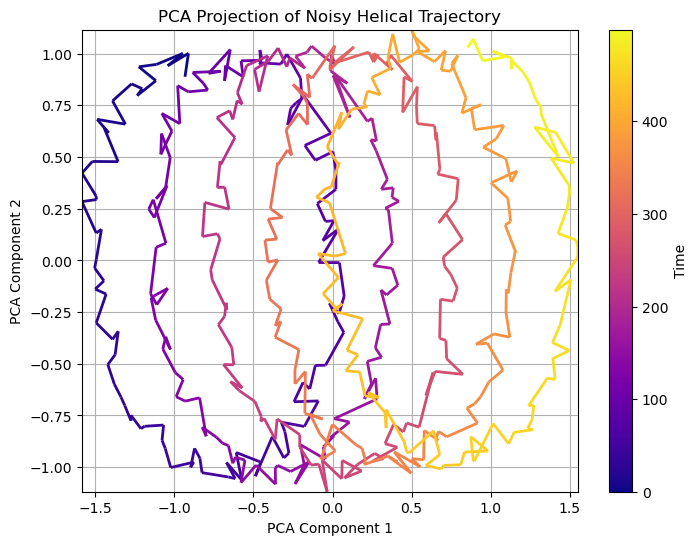

In [5]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(np.column_stack((x, y, z)))
fig , ax = plt.subplots(figsize=(8, 6))
ax = color_plot(pca_result[:, 0], pca_result[:, 1],fig = fig, ax = ax, colorbar=True)
plt.title('PCA Projection of Noisy Helical Trajectory')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

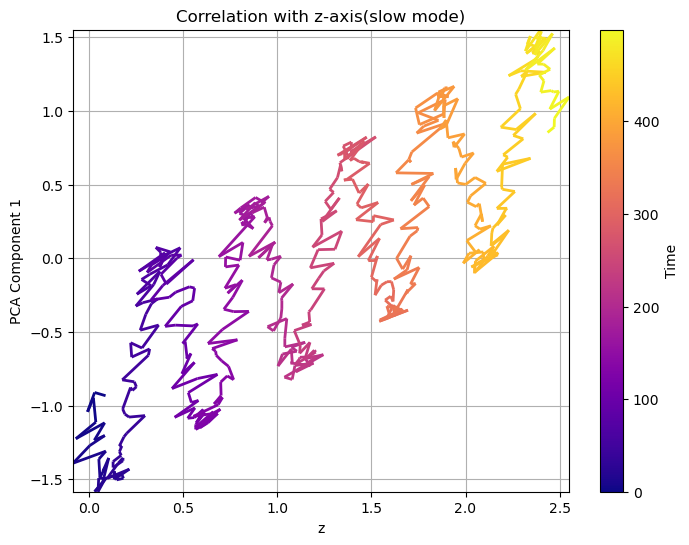

In [6]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(np.column_stack((x, y, z)))
fig , ax = plt.subplots(figsize=(8, 6))
ax = color_plot(z, pca_result[:, 0],fig = fig, ax = ax, colorbar=True)
plt.title('Correlation with z-axis(slow mode)')
plt.xlabel('z')
plt.ylabel('PCA Component 1')
plt.show()

## Dataset size dependency

In [7]:
# Function to plot 3D trajectory and its 2D projection
def plot_helix_pca_turns(turn):

    x, y, z = generate_noisy_helix(turns = turn)
    fig = plt.figure(figsize=(18, 6))

    # 3D Plot
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.plot(x, y, z, label='_', color='blue')
    ax1.set_title(f'Turn = {turn}')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()

    # 2D Projection (XY plane)

    pca = PCA(n_components=3)
    pca_result = pca.fit_transform(np.column_stack((x, y, z)))
    ax2 = fig.add_subplot(132)
    ax2 = color_plot(pca_result[:, 0],pca_result[:, 1], fig = fig, ax = ax2, colorbar=False)
    ax2.set_title('2D Projection (PC1-PC2)')
    ax2.set_xlabel('PCA component 1')
    ax2.set_ylabel('PCA component 2')
    #ax2.axis('equal')

    ax3 = fig.add_subplot(133)
    ax3 = color_plot(z, pca_result[:, 0],fig = fig, ax = ax3, colorbar=False)
    ax3.set_title('Correlation with z-axis')
    ax3.set_xlabel('Z')
    ax3.set_ylabel('PCA component 1')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2725092/2837350585.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


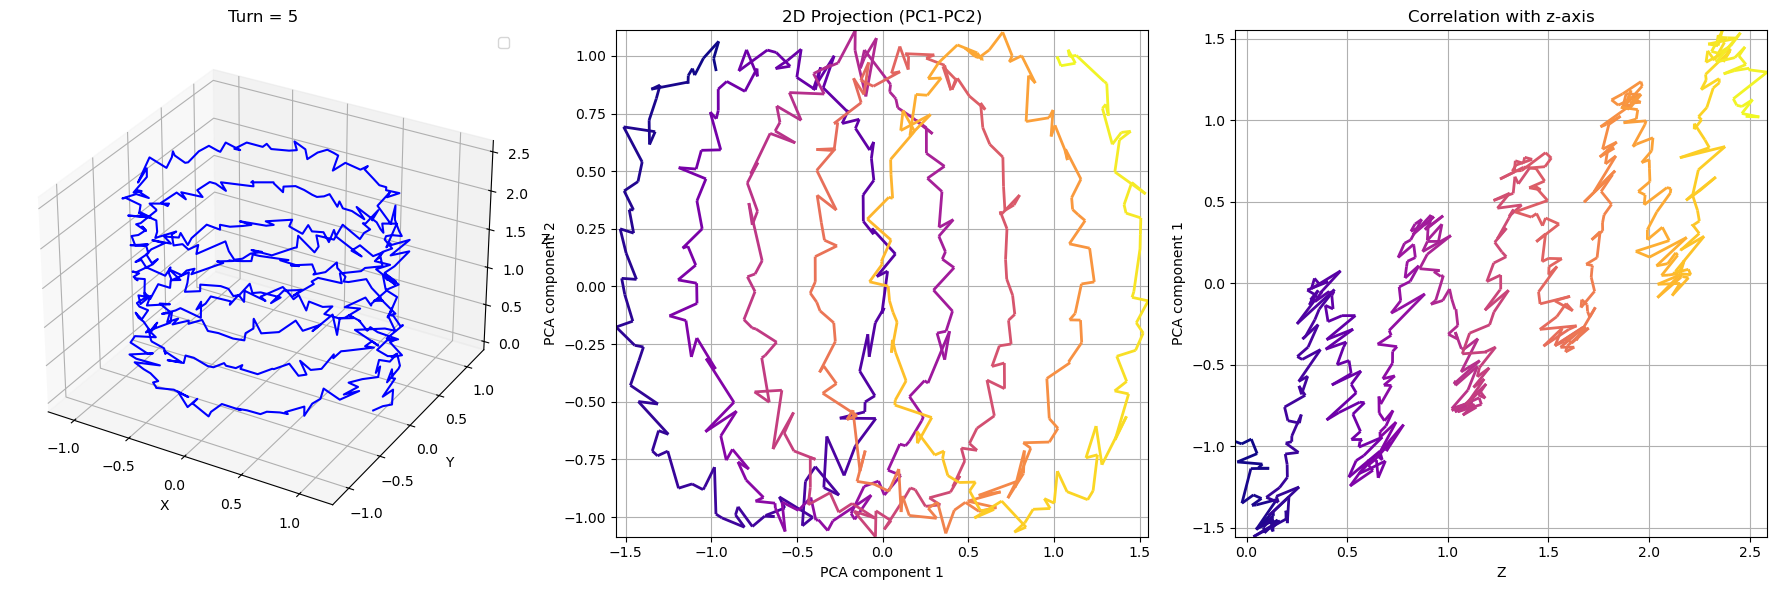

In [8]:
plot_helix_pca_turns(5)

/tmp/ipykernel_2725092/2837350585.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


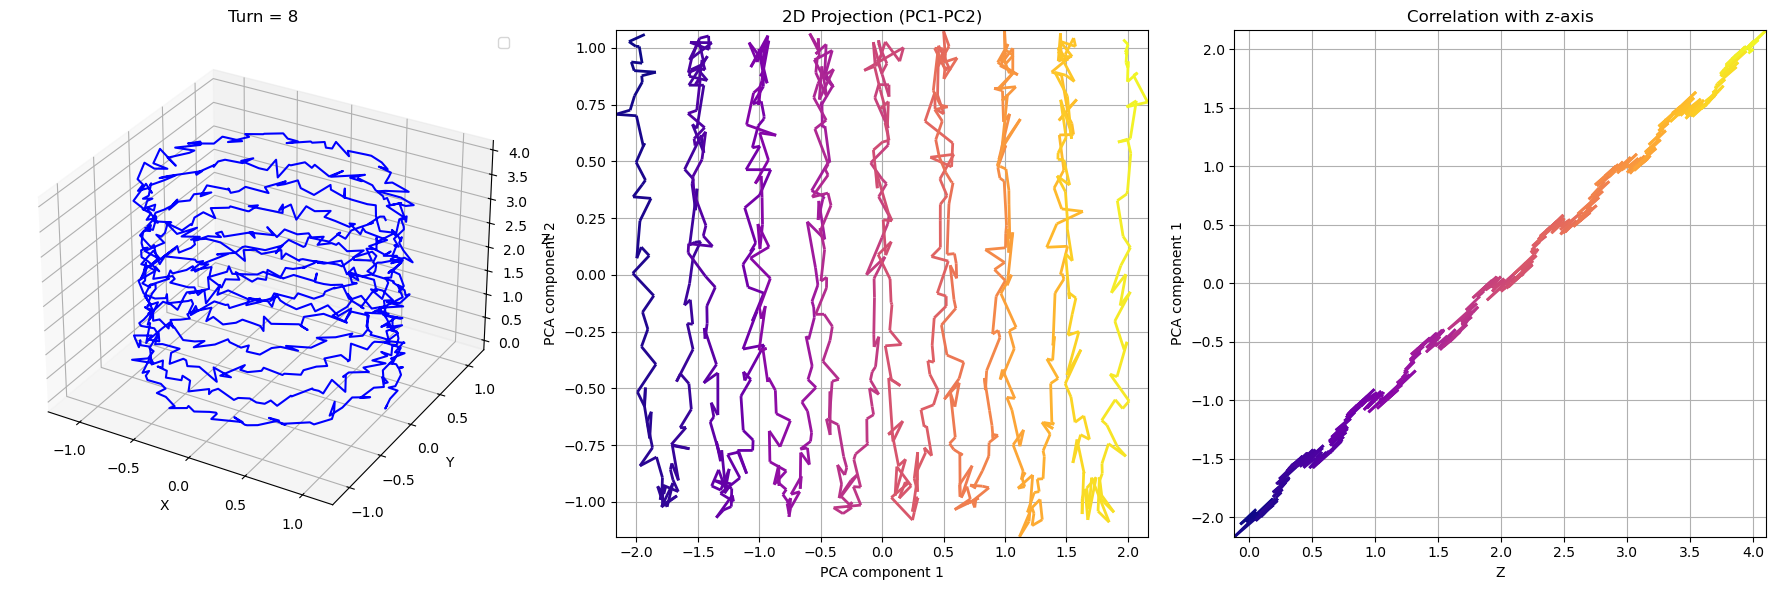

In [9]:
plot_helix_pca_turns(8)

/tmp/ipykernel_2725092/2837350585.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


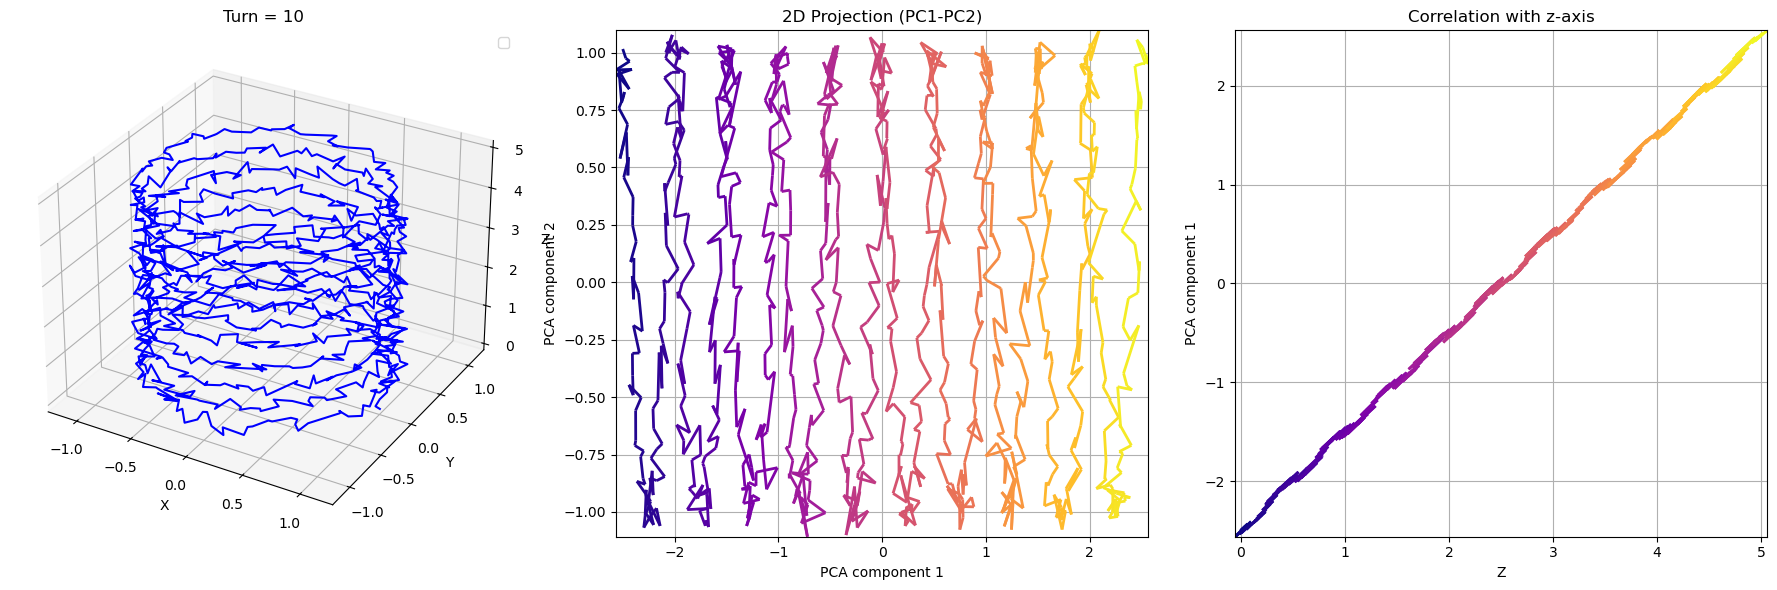

In [10]:
plot_helix_pca_turns(10)

/tmp/ipykernel_2725092/2837350585.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


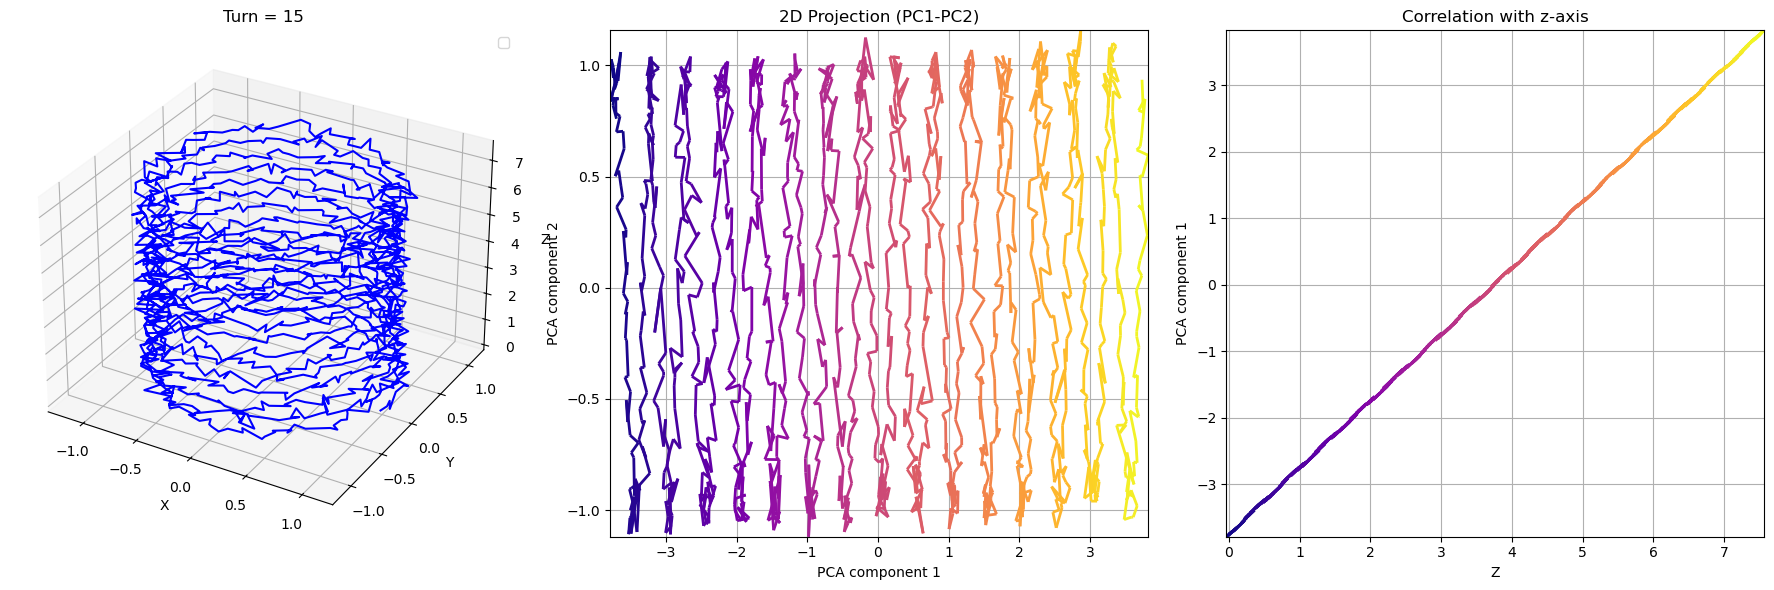

In [11]:
plot_helix_pca_turns(15)

As the dataset size increases, the first principal component increasingly captures the system’s slowest dynamical mode with higher accuracy.

## Tica

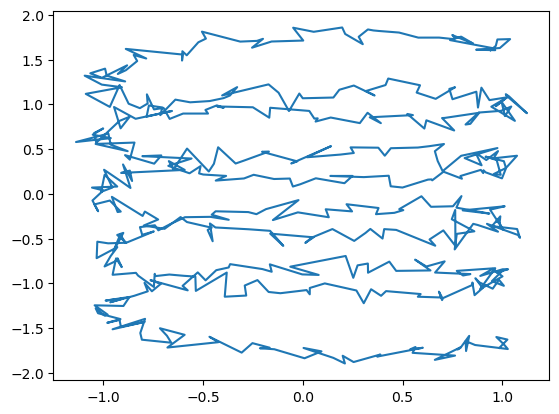

In [12]:
x,y,z = generate_noisy_helix(turns=5)
data = np.column_stack((x, y, z))
tica_model = TICA(lagtime = 1).fit(data)
tica_result = tica_model.transform(data)
plt.plot(x, tica_result[:,0])

In [13]:
# Function to plot 3D trajectory and its 2D projection
def plot_helix_tica_turns(turn, lagtime):

    x, y, z = generate_noisy_helix(turns = turn)
    data = np.column_stack([x, y, z])
    fig = plt.figure(figsize=(18, 6))

    # 3D Plot
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.plot(x, y, z, label='_', color='blue')
    ax1.set_title(f'Turn = {turn}')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.legend()

    # 2D Projection (XY plane)
    tica_model = TICA(lagtime = lagtime).fit(data)
    tica_result = tica_model.transform(data)
    ax2 = fig.add_subplot(132)
    ax2 = color_plot(tica_result[:, 0],tica_result[:, 1], fig = fig, ax = ax2, colorbar=False)
    ax2.set_title(f'2D Projection (IC1-IC2), lagtime = {lagtime}')
    ax2.set_xlabel('IC1')
    ax2.set_ylabel('IC2')
    #ax2.axis('equal')

    ax3 = fig.add_subplot(133)
    ax3 = color_plot(z, tica_result[:, 0],fig = fig, ax = ax3, colorbar=False)
    ax3.set_title(f'Correlation with z-axis,lagtime = {lagtime}')
    ax3.set_xlabel('Z')
    ax3.set_ylabel('PCA component 1')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2725092/2965468614.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


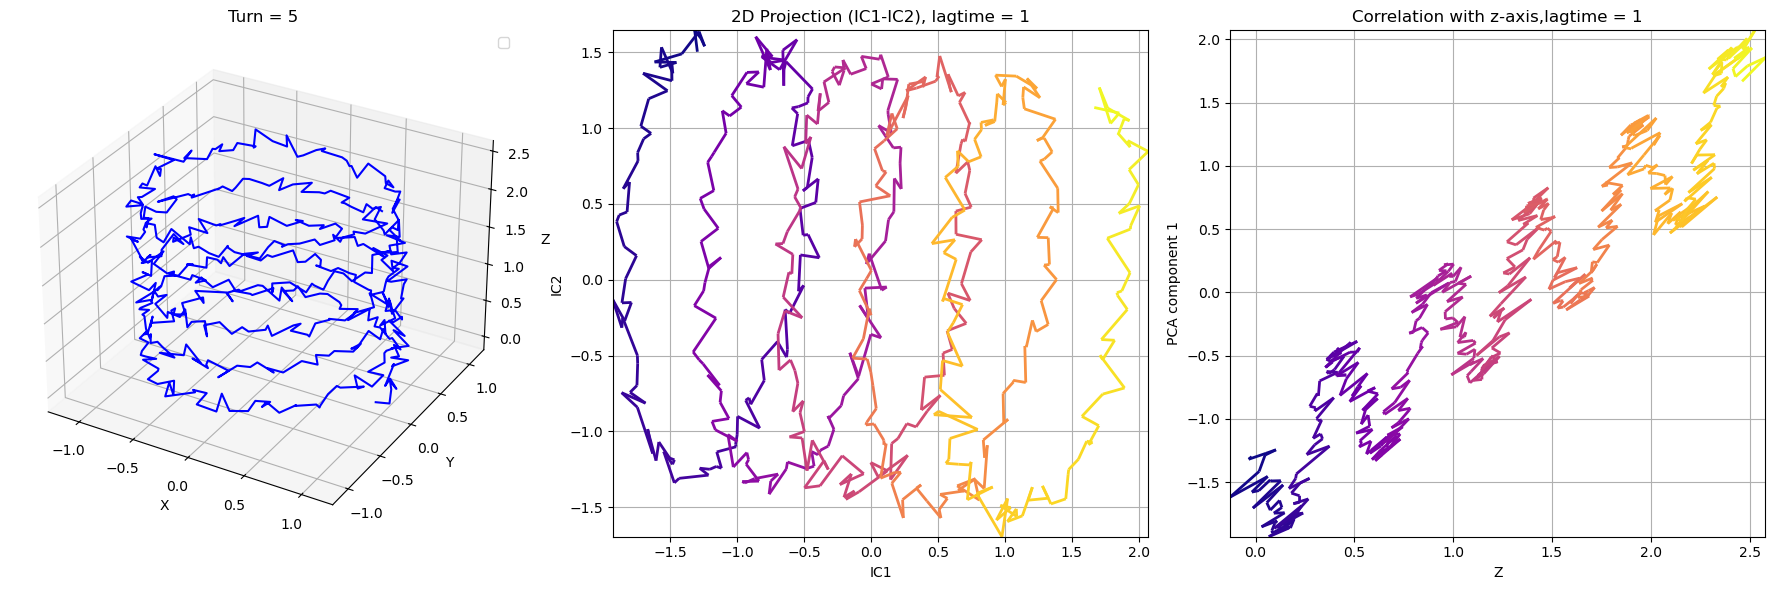

In [14]:
plot_helix_tica_turns(5, lagtime=1)

/tmp/ipykernel_2725092/2965468614.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


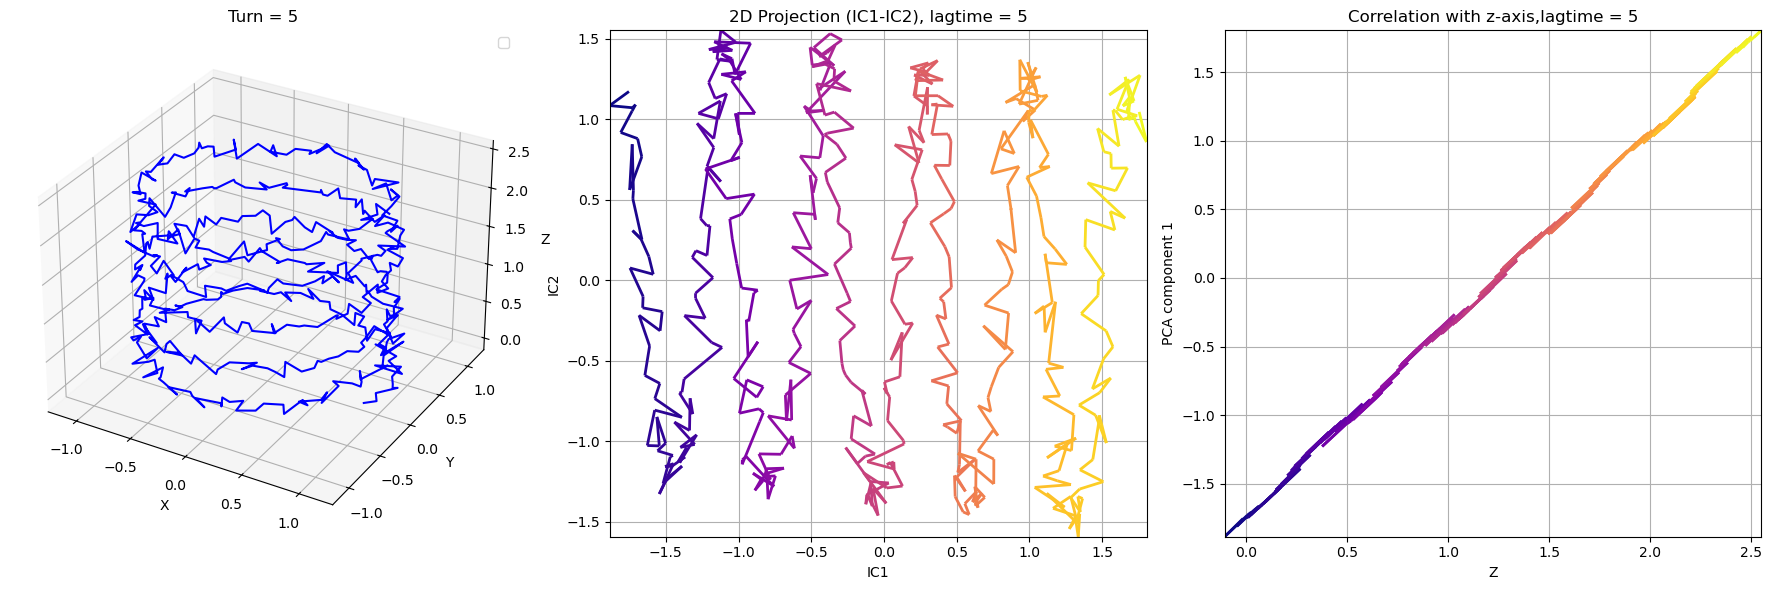

In [15]:
plot_helix_tica_turns(5, lagtime=5)

With less amount of data TICA can learn the slow degrees of mode.